# Практика 7

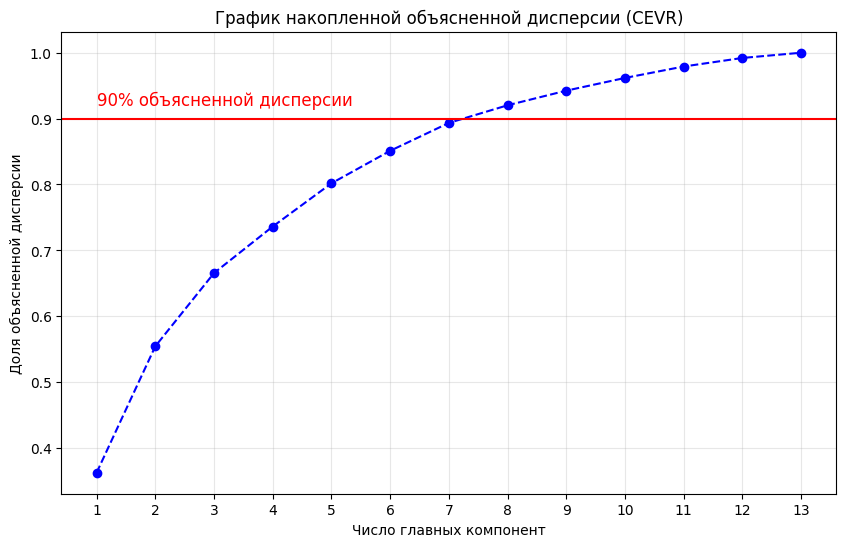

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score 


from sklearn.datasets import load_wine
X, y = load_wine(return_X_y=True)
feature_names = load_wine().feature_names



scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA()
pca_full.fit(X_scaled)

cevr = np.cumsum(pca_full.explained_variance_ratio_)


plt.figure(figsize = (10,6))
plt.plot(range(1,len(cevr) +1 ) , cevr, marker ='o' , linestyle = '--' , color = 'b')

plt.axhline(y = 0.9 , color  = 'r', linestyle = '-')
plt.text(1,0.92, '90% объясненной дисперсии' , color = 'r', fontsize = 12)

plt.title('График накопленной объясненной дисперсии (CEVR)')
plt.xlabel('Число главных компонент')
plt.ylabel('Доля объясненной дисперсии')
plt.xticks(range(1, len(cevr) + 1))
plt.grid(True, alpha = 0.3)
plt.show()






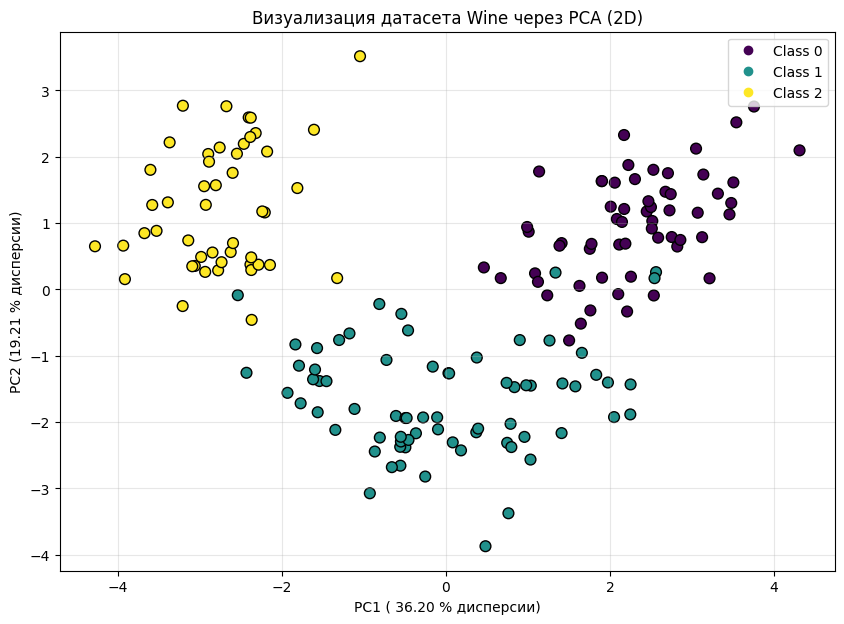

In [26]:
pca_2d = PCA(n_components = 2)
X_pca = pca_2d.fit_transform(X_scaled)

var_pc1 = pca_2d.explained_variance_ratio_[0] * 100 
var_pc2 = pca_2d.explained_variance_ratio_[1] * 100

plt.figure(figsize = (10, 7))

scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1] , c = y , cmap = 'viridis', edgecolors='k', s=60)

plt.legend(handles = scatter.legend_elements()[0] , labels = ['Class 0' , 'Class 1', 'Class 2'])

plt.xlabel(f'PC1 ( {var_pc1:.2f} % дисперсии)')
plt.ylabel(f'PC2 ({var_pc2:.2f} % дисперсии)')

plt.title('Визуализация датасета Wine через PCA (2D)')
plt.grid(True , alpha = 0.3)
plt.show()


In [34]:
loadings = pd.DataFrame(
    pca_2d.components_.T, 
    columns=['PC1', 'PC2'], 
    index=feature_names 
)

print('Топ-3 признака для каждой компоненты:')
print("-" * 30)

for col in ['PC1', 'PC2']: 
    top_3 = loadings[col].abs().sort_values(ascending=False).head(3)
    print(f'Признаки, формирующие {col}:')
    for feature in top_3.index:
        weight = loadings.loc[feature, col] 
        print(f'  * {feature}: {weight:.3f}')


Топ-3 признака для каждой компоненты:
------------------------------
Признаки, формирующие PC1:
  * flavanoids: 0.423
  * total_phenols: 0.395
  * od280/od315_of_diluted_wines: 0.376
Признаки, формирующие PC2:
  * color_intensity: 0.530
  * alcohol: 0.484
  * proline: 0.365


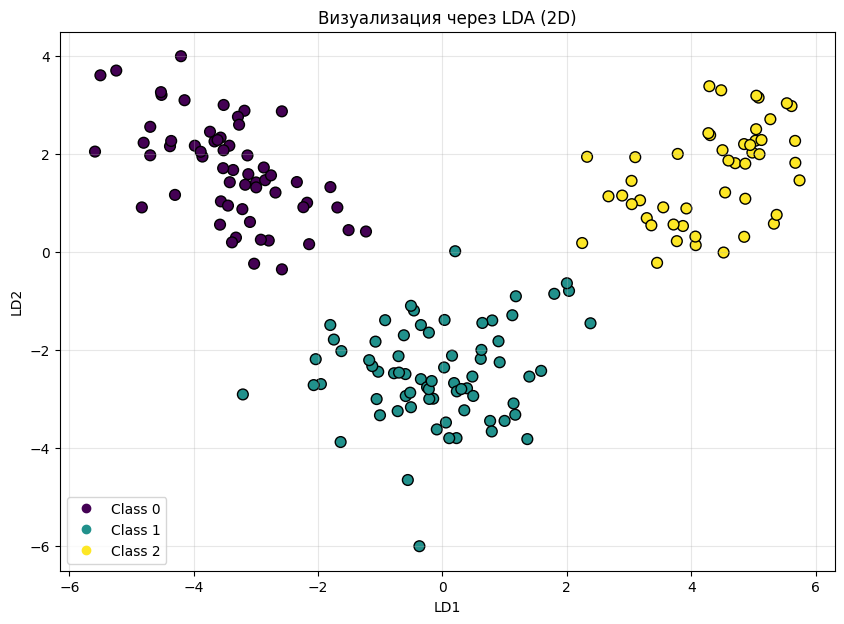

              Метод данных  Точность (Accuracy)
0  Исходные (13 признаков)             0.981481
1       PCA (2 компоненты)             0.962963
2       LDA (2 компоненты)             0.981481


In [38]:
lda = LDA(n_components = 2)
X_lda = lda.fit_transform(X_scaled, y)

plt.figure(figsize = (10,7))
scatter_lda = plt.scatter(X_lda[: , 0] , X_lda[:, 1], c= y , cmap ='viridis' , edgecolors = 'k' , s = 60)
plt.legend(handles=scatter_lda.legend_elements()[0], labels=['Class 0', 'Class 1', 'Class 2'])
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.title('Визуализация через LDA (2D)')
plt.grid(True, alpha=0.3)
plt.show()


X_train, X_test , y_train , y_test = train_test_split(X_scaled , y, test_size = 0.3, random_state = 42)

def get_accuracy(X_tr, X_te, y_tr, y_te):
    model = LogisticRegression()
    model.fit(X_tr, y_tr)
    return accuracy_score(y_te, model.predict(X_te))


acc_raw = get_accuracy(X_train, X_test, y_train, y_test)


pca_final = PCA(n_components=2)
X_train_pca = pca_final.fit_transform(X_train)
X_test_pca = pca_final.transform(X_test)
acc_pca = get_accuracy(X_train_pca, X_test_pca, y_train, y_test)


lda_final = LDA(n_components=2)
X_train_lda = lda_final.fit_transform(X_train, y_train)
X_test_lda = lda_final.transform(X_test)
acc_lda = get_accuracy(X_train_lda, X_test_lda, y_train, y_test)


results = pd.DataFrame({
    'Метод данных': ['Исходные (13 признаков)', 'PCA (2 компоненты)', 'LDA (2 компоненты)'],
    'Точность (Accuracy)': [acc_raw, acc_pca, acc_lda]
})

print(results)